# Logistic Regression

## Objective

The objective of this notebook is to implement a multiclass Logistic Regression model from scratch using NumPy. The implementation includes the Softmax activation function, Cross-Entropy Loss, Gradient Descent optimization, and prediction without using any machine learning libraries.

In [45]:
# Import Required Libraries

import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
# Load scaled datasets

X_train = pd.read_csv("../data/processed/X_train_scaled.csv")
X_test = pd.read_csv("../data/processed/X_test_scaled.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

print("Training Data :", X_train.shape)
print("Testing Data  :", X_test.shape)

Training Data : (1760, 7)
Testing Data  : (440, 7)


In [3]:
# Convert DataFrames into NumPy arrays

X_train = X_train.to_numpy()
X_test = X_test.to_numpy()

y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

## One-Hot Encoding

The target labels are converted into one-hot encoded vectors for multiclass classification.

In [4]:
def one_hot_encode(y, num_classes):

    encoded = np.zeros((len(y), num_classes))

    for i in range(len(y)):
        encoded[i][y[i]] = 1

    return encoded

In [5]:
num_classes = len(np.unique(y_train))

y_train_encoded = one_hot_encode(y_train, num_classes)

## Softmax Function

Softmax converts raw model outputs into probability values that sum to 1 across all classes.

In [6]:
def softmax(z):

    z = z - np.max(z, axis=1, keepdims=True)

    exp = np.exp(z)

    return exp / np.sum(exp, axis=1, keepdims=True)

## Initialize Parameters

Initialize the model weights and bias with zeros.

In [17]:
n_features = X_train.shape[1]
n_classes = num_classes

np.random.seed(42)

weights = np.random.randn(
    n_features,
    n_classes
) * 0.01

bias = np.zeros((1, n_classes))
bias = np.zeros((1, n_classes))

## Cross-Entropy Loss

Cross-Entropy Loss measures the difference between predicted probabilities and the true class labels.

In [18]:
def cross_entropy_loss(y_true, y_pred):

    epsilon = 1e-15

    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    loss = -np.mean(
        np.sum(
            y_true * np.log(y_pred),
            axis=1
        )
    )

    return loss

## Gradient Computation

Compute the gradients of the loss function with respect to the model parameters.

In [19]:
def compute_gradients(X, y_true, y_pred):

    m = X.shape[0]

    dw = (1 / m) * np.dot(X.T, (y_pred - y_true))

    db = (1 / m) * np.sum(
        y_pred - y_true,
        axis=0,
        keepdims=True
    )

    return dw, db

## Training Function

Train the Logistic Regression model using Gradient Descent.

In [20]:
#Training
def train(
    X,
    y,
    learning_rate=0.01,
    epochs=1000
):

    global weights
    global bias

    losses = []

    for epoch in range(epochs):

        logits = np.dot(X, weights) + bias

        predictions = softmax(logits)

        loss = cross_entropy_loss(
            y,
            predictions
        )

        dw, db = compute_gradients(
            X,
            y,
            predictions
        )

        weights -= learning_rate * dw
        bias -= learning_rate * db

        losses.append(loss)

        if epoch % 100 == 0:

            print(
                f"Epoch {epoch} | Loss = {loss:.4f}"
            )

    return losses

In [33]:
#Train Model
losses = train(
    X_train,
    y_train_encoded,
    learning_rate=0.05,
    epochs=20000
)
print("Trained success")

Epoch 0 | Loss = 0.6025
Epoch 100 | Loss = 0.6017
Epoch 200 | Loss = 0.6009
Epoch 300 | Loss = 0.6000
Epoch 400 | Loss = 0.5992
Epoch 500 | Loss = 0.5984
Epoch 600 | Loss = 0.5976
Epoch 700 | Loss = 0.5968
Epoch 800 | Loss = 0.5959
Epoch 900 | Loss = 0.5951
Epoch 1000 | Loss = 0.5943
Epoch 1100 | Loss = 0.5935
Epoch 1200 | Loss = 0.5927
Epoch 1300 | Loss = 0.5919
Epoch 1400 | Loss = 0.5911
Epoch 1500 | Loss = 0.5903
Epoch 1600 | Loss = 0.5895
Epoch 1700 | Loss = 0.5887
Epoch 1800 | Loss = 0.5880
Epoch 1900 | Loss = 0.5872
Epoch 2000 | Loss = 0.5864
Epoch 2100 | Loss = 0.5856
Epoch 2200 | Loss = 0.5848
Epoch 2300 | Loss = 0.5841
Epoch 2400 | Loss = 0.5833
Epoch 2500 | Loss = 0.5825
Epoch 2600 | Loss = 0.5818
Epoch 2700 | Loss = 0.5810
Epoch 2800 | Loss = 0.5802
Epoch 2900 | Loss = 0.5795
Epoch 3000 | Loss = 0.5787
Epoch 3100 | Loss = 0.5780
Epoch 3200 | Loss = 0.5772
Epoch 3300 | Loss = 0.5765
Epoch 3400 | Loss = 0.5757
Epoch 3500 | Loss = 0.5750
Epoch 3600 | Loss = 0.5743
Epoch 3700 | 

In [34]:
#prediction
def predict(X):

    logits = np.dot(X, weights) + bias

    probabilities = softmax(logits)

    return np.argmax(
        probabilities,
        axis=1
    )

In [35]:
#Accuracy
def accuracy(y_true, y_pred):

    return np.mean(y_true == y_pred)

Accuracy : 0.9590909090909091
Precision: 0.9603135649428431
Recall   : 0.959090909090909
F1 Score : 0.9584597126421767


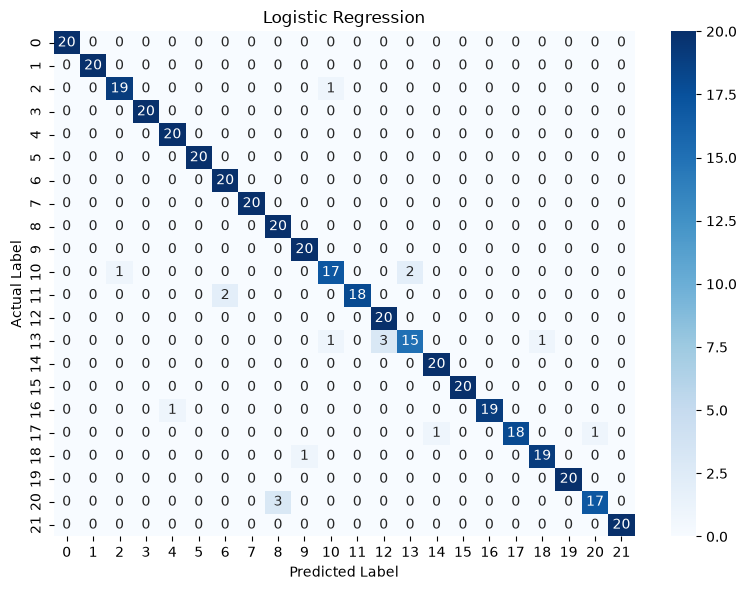

In [46]:
#Evaluate

y_pred = predict(X_test)
def confusion_matrix_scratch(y_true, y_pred, num_classes):
    """
    Generate confusion matrix.
    """
    matrix = np.zeros((num_classes, num_classes), dtype=int)

    for actual, predicted in zip(y_true, y_pred):
        matrix[actual][predicted] += 1

    return matrix

def plot_confusion_matrix(conf_matrix, title):

    plt.figure(figsize=(8, 6))

    sns.heatmap(
        conf_matrix,
        annot=True,
        fmt="d",
        
        cmap="Blues"
    )

    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")

    plt.tight_layout()
    plt.show()

def precision_recall_f1(conf_matrix):
    """
    Calculate Precision, Recall and F1-Score
    for each class and return macro averages.
    """

    num_classes = conf_matrix.shape[0]

    precision_list = []
    recall_list = []
    f1_list = []

    for i in range(num_classes):

        tp = conf_matrix[i, i]

        fp = np.sum(conf_matrix[:, i]) - tp

        fn = np.sum(conf_matrix[i, :]) - tp

        # Precision
        if tp + fp == 0:
            precision = 0
        else:
            precision = tp / (tp + fp)

        # Recall
        if tp + fn == 0:
            recall = 0
        else:
            recall = tp / (tp + fn)

        # F1 Score
        if precision + recall == 0:
            f1 = 0
        else:
            f1 = 2 * precision * recall / (precision + recall)

        precision_list.append(precision)
        recall_list.append(recall)
        f1_list.append(f1)

    return (
        np.mean(precision_list),
        np.mean(recall_list),
        np.mean(f1_list)
    )
    # Accuracy
lr_accuracy = accuracy(y_test, y_pred)

# Confusion Matrix
lr_conf_matrix = confusion_matrix_scratch(
    y_test,
    y_pred,
    num_classes
)

# Metrics
lr_precision, lr_recall, lr_f1 = precision_recall_f1(
    lr_conf_matrix
)

print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)

plot_confusion_matrix(
    lr_conf_matrix,
    "Logistic Regression"
)


In [37]:
#save model
model = {
    "weights": weights,
    "bias": bias
}

with open(
    "../saved_models/logistic_regression.pkl",
    "wb"
) as file:

    pickle.dump(model, file)

print("Model Saved Successfully.")

Model Saved Successfully.
